In [3]:
import tensorflow as tf
import numpy as np
import pandas as pd
import random
import os

SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
split_df = pd.read_csv("/content/drive/MyDrive/DL Assignment/ddr_common_split.csv")
split_df.head()
split_df.head()

,id_code,diagnosis,filepath,exists,split
0,20170209143259326.jpg,0,/content/DDR/DR_grading/DR_grading/20170209143...,True,train
1,007-3253-100.jpg,1,/content/DDR/DR_grading/DR_grading/007-3253-10...,True,train
2,007-6141-300.jpg,2,/content/DDR/DR_grading/DR_grading/007-6141-30...,True,train
3,007-3697-200.jpg,2,/content/DDR/DR_grading/DR_grading/007-3697-20...,True,train
4,007-7323-601.jpg,0,/content/DDR/DR_grading/DR_grading/007-7323-60...,True,train


In [7]:
RESULT_DIR = "/content/drive/MyDrive/DL Assignment/ResNet50_Results"

In [ ]:
!ls "/content/drive/MyDrive/DL Project"


In [ ]:
!ls "/content/drive/MyDrive"


In [ ]:
!ls "/content/drive/MyDrive"

In [ ]:
!ls "/content/drive/MyDrive/DL Project"

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

In [ ]:
!ls "/content/drive/MyDrive/Colab Notebooks"

In [ ]:
import pandas as pd

split_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ddr_common_split.csv")
split_df.head()

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

In [ ]:
!ls "/content/drive/MyDrive/DL Assignment"

In [ ]:
import pandas as pd

split_df = pd.read_csv("/content/drive/MyDrive/DL Assignment/ddr_common_split.csv")
split_df.head()

In [ ]:
print(split_df['exists'].value_counts())

In [ ]:
import os

os.makedirs("/content/DDR", exist_ok=True)

!unzip -q "/content/drive/MyDrive/DL Assignment/DDR.zip" -d "/content/DDR"

In [ ]:
!ls "/content/DDR"

In [ ]:
!ls "/content/DDR/DR_grading/DR_grading" | head -5

In [12]:
split_df['exists'] = split_df['filepath'].apply(os.path.exists)
print(split_df['exists'].value_counts())


exists
False    12522
Name: count, dtype: int64


In [13]:
train_df = split_df[split_df['split'] == 'train'].reset_index(drop=True)
val_df = split_df[split_df['split'] == 'validation'].reset_index(drop=True)
test_df = split_df[split_df['split'] == 'test'].reset_index(drop=True)

print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Testing:", len(test_df))

Training: 8765
Validation: 1878
Testing: 1879


In [14]:
import tensorflow as tf
import numpy as np
import random

SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [9]:
def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    return image, label

def create_dataset(dataframe, training=False):
    paths = dataframe['filepath'].values
    labels = dataframe['diagnosis'].values

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    dataset = dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        dataset = dataset.shuffle(2000, seed=SEED)

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

In [16]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/DL Assignment/DDR.zip"  # exact path confirm කරන්න
extract_path = "/content/"

if not os.path.exists("/content/DDR"):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Extraction done.")
else:
    print("Already extracted.")

Extraction done.


In [20]:
import os
print(os.listdir("/content/"))

['.config', 'drive', 'DR_grading.csv', 'DR_grading', 'sample_data']


In [22]:
import os
if not os.path.exists("/content/DDR"):
    os.symlink("/content/", "/content/DDR")

print(os.path.exists(split_df['filepath'].iloc[0]))

True


In [21]:
print(os.listdir("/content/DR_grading")[:10])
print(os.path.exists("/content/DR_grading/DR_grading"))

['DR_grading']
True


In [19]:
import os
print(os.path.exists("/content/DDR"))
print(os.listdir("/content/DDR")[:10] if os.path.exists("/content/DDR") else "DDR folder not found")
print(split_df['filepath'].iloc[0])
print(os.path.exists(split_df['filepath'].iloc[0]))

False
DDR folder not found
/content/DDR/DR_grading/DR_grading/20170209143259326.jpg
False


In [23]:
train_dataset = create_dataset(train_df, training=True)
val_dataset = create_dataset(val_df)
test_dataset = create_dataset(test_df)

# Quick check
for images, labels in train_dataset.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 224, 224, 3)
Labels shape: (32,)


In [24]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.10)
])

In [25]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(train_df['diagnosis'])
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_df['diagnosis']
)
class_weights = dict(zip(classes, weights))
print(class_weights)

{np.int64(0): np.float64(0.3996808025535796), np.int64(1): np.float64(3.9750566893424035), np.int64(2): np.float64(0.5593490746649649), np.int64(3): np.float64(10.624242424242425), np.int64(4): np.float64(2.7433489827856024)}


In [26]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, Model

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False   # Phase 1: freeze backbone

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = data_augmentation(inputs)
x = tf.keras.applications.resnet50.preprocess_input(x)
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(5, activation='softmax')(x)

resnet_model = Model(inputs, outputs)
resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    262,272 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 5)         │        645 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,850,629 (90.98 MB)

 Trainable params: 262,917 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [27]:
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [29]:
class_names = globals().get("CLASS_NAMES", [str(i) for i in range(5)])
print(class_names)

['0', '1', '2', '3', '4']


In [30]:
import pandas as pd
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             roc_auc_score, cohen_kappa_score)

def evaluate_on_val(checkpoint_path):
    resnet_model.load_weights(checkpoint_path)
    val_loss, val_acc = resnet_model.evaluate(val_dataset, verbose=0)

    y_true_v, y_prob_v = [], []
    for images, labels in val_dataset:
        y_true_v.extend(labels.numpy())
        y_prob_v.extend(resnet_model.predict(images, verbose=0))
    y_true_v = np.array(y_true_v)
    y_prob_v = np.array(y_prob_v)
    y_pred_v = np.argmax(y_prob_v, axis=1)

    return {
        "val_loss": val_loss,
        "val_accuracy": val_acc,
        "precision_macro": precision_score(y_true_v, y_pred_v, average='macro', zero_division=0),
        "recall_macro": recall_score(y_true_v, y_pred_v, average='macro', zero_division=0),
        "f1_macro": f1_score(y_true_v, y_pred_v, average='macro', zero_division=0),
        "auc_macro": roc_auc_score(y_true_v, y_prob_v, multi_class='ovr', average='macro'),
        "qwk": cohen_kappa_score(y_true_v, y_pred_v, weights='quadratic'),
    }

checkpoints = {
    "v1": f"{RESULT_DIR}/best_resnet50_final.keras",
    "v2": f"{RESULT_DIR}/best_resnet50_final_v2.keras",
    "v3": f"{RESULT_DIR}/best_resnet50_final_v3.keras",
}

val_comparison = {}
for name, path in checkpoints.items():
    print(f"Evaluating {name} on validation set...")
    val_comparison[name] = evaluate_on_val(path)

val_comparison_df = pd.DataFrame(val_comparison).T
print("\nValidation-set comparison:\n")
print(val_comparison_df)

val_comparison_df.to_csv(f"{RESULT_DIR}/resnet50_val_model_selection.csv")
best_version = val_comparison_df["f1_macro"].astype(float).idxmax()
print(f"\nBest model by validation macro-F1: {best_version}")
resnet_model.load_weights(checkpoints[best_version])

Evaluating v1 on validation set...


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 82 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Evaluating v2 on validation set...


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 46 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Evaluating v3 on validation set...


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 46 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



Validation-set comparison:

    val_loss  val_accuracy  precision_macro  recall_macro  f1_macro  \
v1  0.940617      0.593717         0.471331      0.510292  0.460487   
v2  0.863307      0.616613         0.511380      0.532403  0.477492   
v3  0.685793      0.742279         0.572983      0.535623  0.542524   

    auc_macro       qwk  
v1   0.840007  0.653014  
v2   0.873597  0.705348  
v3   0.888709  0.747229  

Best model by validation macro-F1: v3


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 46 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
import os

RESULT_DIR = "/content/drive/MyDrive/DL Assignment/ResNet50_Results"
os.makedirs(RESULT_DIR, exist_ok=True)

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    ModelCheckpoint(f"{RESULT_DIR}/best_resnet50_phase1.keras", monitor='val_loss', save_best_only=True, verbose=1)
]

In [ ]:
import time

start_time = time.time()

history1 = resnet_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks
)

phase1_time = time.time() - start_time
print("Phase 1 time (min):", phase1_time / 60)

In [ ]:
base_model.trainable = True

# ResNet50 එකේ මුල් layers ටික freeze කරලම තියාගන්න, අන්තිම ~30 layers විතරක් unfreeze කරන්න
fine_tune_at = len(base_model.layers) - 30

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # much smaller LR
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Check trainable params now
resnet_model.summary()

In [ ]:
callbacks_phase2 = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1),
    ModelCheckpoint(f"{RESULT_DIR}/best_resnet50_final.keras", monitor='val_loss', save_best_only=True, verbose=1)
]

In [ ]:
start_time2 = time.time()

history2 = resnet_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks_phase2
)

phase2_time = time.time() - start_time2
total_training_time = phase1_time + phase2_time

print("Phase 2 time (min):", phase2_time / 60)
print("Total training time (min):", total_training_time / 60)

In [ ]:
total_training_time = phase1_time + phase2_time
print("Total training time (min):", total_training_time / 60)

In [ ]:
test_loss, test_accuracy = resnet_model.evaluate(test_dataset)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

In [ ]:
y_true = []
y_prob = []

for images, labels in test_dataset:
    predictions = resnet_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_prob.extend(predictions)

y_true = np.array(y_true)
y_prob = np.array(y_prob)
y_pred = np.argmax(y_prob, axis=1)

print("Predictions done. Shape:", y_prob.shape)

In [ ]:
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             roc_auc_score, cohen_kappa_score,
                             confusion_matrix, classification_report)
import seaborn as sns
import matplotlib.pyplot as plt

num_classes = y_prob.shape[1]
class_names = globals().get("CLASS_NAMES", [str(i) for i in range(num_classes)])

precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall    = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1        = f1_score(y_true, y_pred, average='macro', zero_division=0)
auc       = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
qwk       = cohen_kappa_score(y_true, y_pred, weights='quadratic')

print(f"Test Accuracy    : {test_accuracy:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro)   : {recall:.4f}")
print(f"F1 (macro)       : {f1:.4f}")
print(f"AUC (OvR macro)  : {auc:.4f}")
print(f"QWK              : {qwk:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("ResNet50 Confusion Matrix")
plt.tight_layout()
plt.savefig(f"{RESULT_DIR}/resnet50_confusion_matrix.png", dpi=300)
plt.show()

In [ ]:
# Phase 1 හොඳම weights වලින් නැවත පටන් ගන්න
resnet_model.load_weights(f"{RESULT_DIR}/best_resnet50_phase1.keras")

base_model.trainable = True
fine_tune_at = len(base_model.layers) - 60   # 30 → 60

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# BatchNorm layers frozen තියාගන්න
for layer in base_model.layers[fine_tune_at:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
print("Trainable variables:", len(resnet_model.trainable_variables))
resnet_model.summary()

In [ ]:
callbacks_phase2 = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1),
    ModelCheckpoint(f"{RESULT_DIR}/best_resnet50_final_v2.keras", monitor='val_loss', save_best_only=True, verbose=1)
]

In [ ]:
start_time2 = time.time()

history2 = resnet_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks_phase2
)

phase2_time = time.time() - start_time2
total_training_time = phase1_time + phase2_time
print("Phase 2 time (min):", phase2_time / 60)
print("Total training time (min):", total_training_time / 60)

In [ ]:
plt.savefig(f"{RESULT_DIR}/resnet50_v2_confusion_matrix.png", dpi=300)
plt.title("ResNet50 v2 Confusion Matrix")

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("ResNet50 v2 Confusion Matrix")
plt.tight_layout()
plt.savefig(f"{RESULT_DIR}/resnet50_v2_confusion_matrix.png", dpi=300)  # show එකට කලින්
plt.show()

In [ ]:

y_pred_v1 = y_pred.copy()
y_prob_v1 = y_prob.copy()


test_loss, test_accuracy = resnet_model.evaluate(test_dataset)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


y_true, y_prob = [], []
for images, labels in test_dataset:
    y_true.extend(labels.numpy())
    y_prob.extend(resnet_model.predict(images, verbose=0))

y_true = np.array(y_true)
y_prob = np.array(y_prob)
y_pred = np.argmax(y_prob, axis=1)

print("Predictions done. Shape:", y_prob.shape)
print("v1 එකෙන් වෙනස් වුණ predictions ගණන:", (y_pred != y_pred_v1).sum())

In [ ]:
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             roc_auc_score, cohen_kappa_score,
                             confusion_matrix, classification_report)
import seaborn as sns
import matplotlib.pyplot as plt

num_classes = y_prob.shape[1]
class_names = globals().get("CLASS_NAMES", [str(i) for i in range(num_classes)])

precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall    = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1        = f1_score(y_true, y_pred, average='macro', zero_division=0)
auc       = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
qwk       = cohen_kappa_score(y_true, y_pred, weights='quadratic')

print(f"Test Accuracy    : {test_accuracy:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro)   : {recall:.4f}")
print(f"F1 (macro)       : {f1:.4f}")
print(f"AUC (OvR macro)  : {auc:.4f}")
print(f"QWK              : {qwk:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("ResNet50 v2 Confusion Matrix")
plt.tight_layout()
plt.savefig(f"{RESULT_DIR}/resnet50_v2_confusion_matrix.png", dpi=300)
plt.show()

In [ ]:

class_weights_soft = {k: float(np.sqrt(v)) for k, v in class_weights.items()}
print(class_weights_soft)

In [ ]:

y_pred_v2 = y_pred.copy()
y_prob_v2 = y_prob.copy()
test_acc_v2 = test_accuracy


class_weights_soft = {int(k): float(np.sqrt(v)) for k, v in class_weights.items()}
print(class_weights_soft)


resnet_model.load_weights(f"{RESULT_DIR}/best_resnet50_phase1.keras")

base_model.trainable = True
fine_tune_at = len(base_model.layers) - 60

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base_model.layers[fine_tune_at:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase2_v3 = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1),
    ModelCheckpoint(f"{RESULT_DIR}/best_resnet50_final_v3.keras",
                    monitor='val_loss', save_best_only=True, verbose=1)
]

start_time3 = time.time()
history3 = resnet_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,
    class_weight=class_weights_soft,
    callbacks=callbacks_phase2_v3
)
phase2_v3_time = time.time() - start_time3

print("Phase 2 (v3) time (min):", phase2_v3_time / 60)
print("Total training time v3 (min):", (phase1_time + phase2_v3_time) / 60)

In [ ]:
test_loss, test_accuracy = resnet_model.evaluate(test_dataset)
print("Test Loss:", test_loss, "| Test Accuracy:", test_accuracy)

y_true, y_prob = [], []
for images, labels in test_dataset:
    y_true.extend(labels.numpy())
    y_prob.extend(resnet_model.predict(images, verbose=0))
y_true = np.array(y_true); y_prob = np.array(y_prob)
y_pred = np.argmax(y_prob, axis=1)
print("v2 එකෙන් වෙනස් වුණ predictions:", (y_pred != y_pred_v2).sum())

precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall    = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1        = f1_score(y_true, y_pred, average='macro', zero_division=0)
auc       = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
qwk       = cohen_kappa_score(y_true, y_pred, weights='quadratic')

print(f"Test Accuracy    : {test_accuracy:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro)   : {recall:.4f}")
print(f"F1 (macro)       : {f1:.4f}")
print(f"AUC (OvR macro)  : {auc:.4f}")
print(f"QWK              : {qwk:.4f}")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("ResNet50 v3 Confusion Matrix")
plt.tight_layout()
plt.savefig(f"{RESULT_DIR}/resnet50_v3_confusion_matrix.png", dpi=300)
plt.show()

In [ ]:
import json, pandas as pd

# ---------- 1. Results JSON + CSV ----------
best_epoch_v3 = int(np.argmin(history3.history['val_loss'])) + 1

report_dict = classification_report(y_true, y_pred, target_names=class_names,
                                    zero_division=0, output_dict=True)

results_v3 = {
    "model": "ResNet50 v3 (soft class weights, last 60 layers unfrozen, BN frozen)",
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "precision_macro": float(precision),
    "recall_macro": float(recall),
    "f1_macro": float(f1),
    "auc_ovr_macro": float(auc),
    "qwk": float(qwk),
    "best_val_loss": float(min(history3.history['val_loss'])),
    "best_val_accuracy": float(history3.history['val_accuracy'][best_epoch_v3 - 1]),
    "best_epoch_phase2": best_epoch_v3,
    "phase1_time_min": float(phase1_time / 60),
    "phase2_time_min": float(phase2_v3_time / 60),
    "total_training_time_min": float((phase1_time + phase2_v3_time) / 60),
    "total_params": int(resnet_model.count_params()),
    "model_path": f"{RESULT_DIR}/best_resnet50_final_v3.keras",
    "per_class": report_dict,
}

with open(f"{RESULT_DIR}/resnet50_v3_results.json", "w") as f:
    json.dump(results_v3, f, indent=2)

pd.DataFrame(report_dict).T.to_csv(f"{RESULT_DIR}/resnet50_v3_classification_report.csv")

# v1 / v2 / v3 සසඳන table එක
comparison = pd.DataFrame({
    "version":  ["v1", "v2", "v3"],
    "test_acc": [0.5870, 0.6301, float(test_accuracy)],
    "test_loss":[0.9028, 0.8514, float(test_loss)],
    "macro_f1": [0.46, 0.4950, float(f1)],
    "auc":      [None, 0.8803, float(auc)],
    "qwk":      [0.67, 0.7203, float(qwk)],
})
comparison.to_csv(f"{RESULT_DIR}/resnet50_v1_v2_v3_comparison.csv", index=False)
print(comparison)

# ---------- 2. Training curves (Phase 1 + Phase 2 v3) ----------
def cat(key):
    return history.history[key] + history3.history[key]

n1 = len(history.history['loss'])
epochs_all = range(1, len(cat('loss')) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (tr, va, title) in zip(axes, [("accuracy", "val_accuracy", "Accuracy"),
                                       ("loss", "val_loss", "Loss")]):
    ax.plot(epochs_all, cat(tr), label="Train")
    ax.plot(epochs_all, cat(va), label="Validation")
    ax.axvline(n1 + 0.5, color="gray", linestyle="--", label="Phase 1 → Phase 2")
    ax.set_xlabel("Epoch"); ax.set_title(f"ResNet50 v3 - {title}")
    ax.legend()
plt.tight_layout()
plt.savefig(f"{RESULT_DIR}/resnet50_v3_training_curves.png", dpi=300)
plt.show()

In [ ]:
from tensorflow.keras.callbacks import History
print([k for k, v in globals().items() if isinstance(v, History)])

In [ ]:
hist_p1 = history1

def cat(key):
    return hist_p1.history[key] + history3.history[key]

n1 = len(hist_p1.history['loss'])
epochs_all = range(1, len(cat('loss')) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (tr, va, title) in zip(axes, [("accuracy", "val_accuracy", "Accuracy"),
                                       ("loss", "val_loss", "Loss")]):
    ax.plot(epochs_all, cat(tr), label="Train")
    ax.plot(epochs_all, cat(va), label="Validation")
    ax.axvline(n1 + 0.5, color="gray", linestyle="--", label="Phase 1 → Phase 2")
    ax.set_xlabel("Epoch"); ax.set_title(f"ResNet50 v3 - {title}")
    ax.legend()
plt.tight_layout()
plt.savefig(f"{RESULT_DIR}/resnet50_v3_training_curves.png", dpi=300)
plt.show()

In [ ]:
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             roc_auc_score, cohen_kappa_score)

def evaluate_on_val(checkpoint_path):
    resnet_model.load_weights(checkpoint_path)
    val_loss, val_acc = resnet_model.evaluate(val_dataset, verbose=0)

    y_true_v, y_prob_v = [], []
    for images, labels in val_dataset:
        y_true_v.extend(labels.numpy())
        y_prob_v.extend(resnet_model.predict(images, verbose=0))
    y_true_v = np.array(y_true_v)
    y_prob_v = np.array(y_prob_v)
    y_pred_v = np.argmax(y_prob_v, axis=1)

    return {
        "val_loss": val_loss,
        "val_accuracy": val_acc,
        "precision_macro": precision_score(y_true_v, y_pred_v, average='macro', zero_division=0),
        "recall_macro": recall_score(y_true_v, y_pred_v, average='macro', zero_division=0),
        "f1_macro": f1_score(y_true_v, y_pred_v, average='macro', zero_division=0),
        "auc_macro": roc_auc_score(y_true_v, y_prob_v, multi_class='ovr', average='macro'),
        "qwk": cohen_kappa_score(y_true_v, y_pred_v, weights='quadratic'),
    }

checkpoints = {
    "v1": f"{RESULT_DIR}/best_resnet50_final.keras",
    "v2": f"{RESULT_DIR}/best_resnet50_final_v2.keras",
    "v3": f"{RESULT_DIR}/best_resnet50_final_v3.keras",
}

val_comparison = {}
for name, path in checkpoints.items():
    print(f"Evaluating {name} on validation set...")
    val_comparison[name] = evaluate_on_val(path)

val_comparison_df = pd.DataFrame(val_comparison).T
print("\nValidation-set comparison (model selection basis):\n")
print(val_comparison_df)

val_comparison_df.to_csv(f"{RESULT_DIR}/resnet50_val_model_selection.csv")


best_version = val_comparison_df["f1_macro"].astype(float).idxmax()
print(f"\nBest model by validation macro-F1: {best_version}")
resnet_model.load_weights(checkpoints[best_version])

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

Test Accuracy: 0.7514635324478149 | Test Loss: 0.6677411198616028


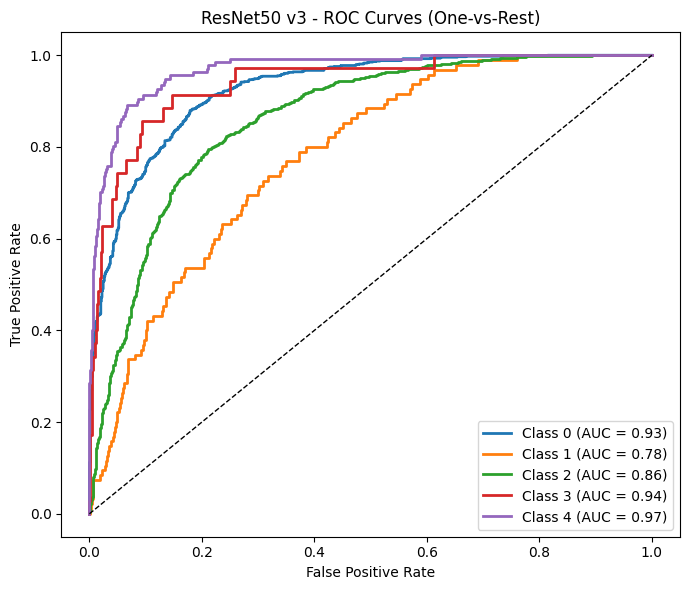

In [33]:
from sklearn.metrics import roc_curve, auc
from itertools import cycle

test_loss, test_accuracy = resnet_model.evaluate(test_dataset, verbose=0)
y_true, y_prob = [], []
for images, labels in test_dataset:
    y_true.extend(labels.numpy())
    y_prob.extend(resnet_model.predict(images, verbose=0))
y_true = np.array(y_true)
y_prob = np.array(y_prob)
y_pred = np.argmax(y_prob, axis=1)
print("Test Accuracy:", test_accuracy, "| Test Loss:", test_loss)

n_classes = y_prob.shape[1]
y_true_bin = tf.keras.utils.to_categorical(y_true, num_classes=n_classes)

plt.figure(figsize=(7, 6))
colors = cycle(['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc_i = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f"Class {class_names[i]} (AUC = {roc_auc_i:.2f})")
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ResNet50 v3 - ROC Curves (One-vs-Rest)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(f"{RESULT_DIR}/resnet50_v3_roc_curves.png", dpi=300)
plt.show()

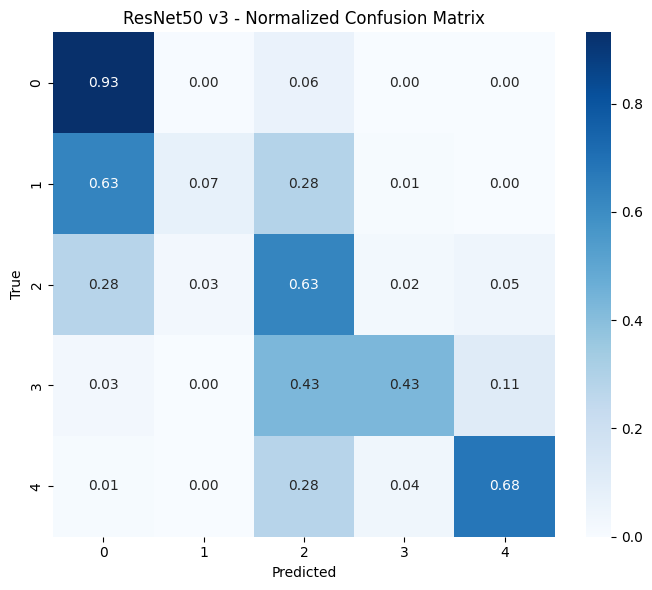

In [34]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(7, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("ResNet50 v3 - Normalized Confusion Matrix")
plt.tight_layout()
plt.savefig(f"{RESULT_DIR}/resnet50_v3_confusion_matrix_normalized.png", dpi=300)
plt.show()

In [35]:
import time

_ = resnet_model.predict(next(iter(test_dataset))[0], verbose=0)  # warm-up

times = []
for i, (images, labels) in enumerate(test_dataset):
    if i >= 20:
        break
    start = time.time()
    _ = resnet_model.predict(images, verbose=0)
    times.append((time.time() - start) / images.shape[0])

avg_inference_ms = np.mean(times) * 1000
print(f"Average inference time per image: {avg_inference_ms:.2f} ms")

import json
with open(f"{RESULT_DIR}/resnet50_v3_results.json", "r") as f:
    results_v3 = json.load(f)
results_v3["inference_time_ms_per_image"] = float(avg_inference_ms)
results_v3["val_model_selection"] = val_comparison_df.to_dict()
with open(f"{RESULT_DIR}/resnet50_v3_results.json", "w") as f:
    json.dump(results_v3, f, indent=2)
print("Updated results JSON saved.")

Average inference time per image: 16.12 ms
Updated results JSON saved.
